# 03 · TYK2 as a target in ankylosing spondylitis: evidence, selectivity and candidates

Notebook 02 characterised the TYK2 chemistry. This one asks the project's actual questions:

1. How good is the evidence that TYK2 is a target in **ankylosing spondylitis (AS)** specifically?
2. Can TYK2 be inhibited **selectively** over JAK1/2/3, which is what separates it from the JAK inhibitor class?
3. Which compounds in ChEMBL look like credible starting points, and does the approach recover the drug that already works?

Run `python run_pipeline.py` first (or the scripts in `src/` in order).

## 1. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from rdkit import Chem
from rdkit.Chem import Draw

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIG_DIR = ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)

BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
GREY, TEXT_2 = "#8a8984", "#52514e"
DOMAIN_COLORS = {"JH2": BLUE, "JH1": ORANGE, "Other": GREY}

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.labelcolor": TEXT_2,
    "axes.edgecolor": "#c9c8c3", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#ecebe7", "grid.linewidth": 0.8, "axes.axisbelow": True,
    "xtick.color": TEXT_2, "ytick.color": TEXT_2, "legend.frameon": False,
})

def save(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png")

OT = ROOT / "data/raw/opentargets"
PROC = ROOT / "data/processed"
RES = ROOT / "results"

## 2. Is TYK2 a credible target in ankylosing spondylitis?

Open Targets aggregates genetic, clinical and literature evidence per target-disease pair.
The scores below are theirs, not ours.

In [2]:
assoc = pd.read_csv(OT / "as_associated_targets.csv")
highlight = ["TNF", "IL17A", "IL23R", "ERAP1", "IL12B", "JAK1", "JAK2", "JAK3", "TYK2"]
print(f"TYK2 rank among AS-associated targets: "
      f"{int(assoc.loc[assoc['symbol'] == 'TYK2', 'rank'].iloc[0])} of {len(assoc)} shown")
assoc[assoc["symbol"].isin(highlight)][
    ["rank", "symbol", "overall_score", "genetic_association", "clinical", "literature"]
].round(2)

TYK2 rank among AS-associated targets: 10 of 100 shown


,rank,symbol,overall_score,genetic_association,clinical,literature
0,1,TNF,0.62,0.00,0.99,0.65
3,4,IL17A,0.60,0.00,0.96,0.45
4,5,JAK2,0.58,0.49,0.82,0.10
9,10,TYK2,0.51,0.09,0.82,0.07
10,11,ERAP1,0.51,0.82,0.00,0.28
11,12,IL23R,0.51,0.82,0.00,0.18
12,13,JAK1,0.50,0.00,0.82,0.16
13,14,JAK3,0.50,0.00,0.82,0.03
23,24,IL12B,0.38,0.43,0.51,0.43


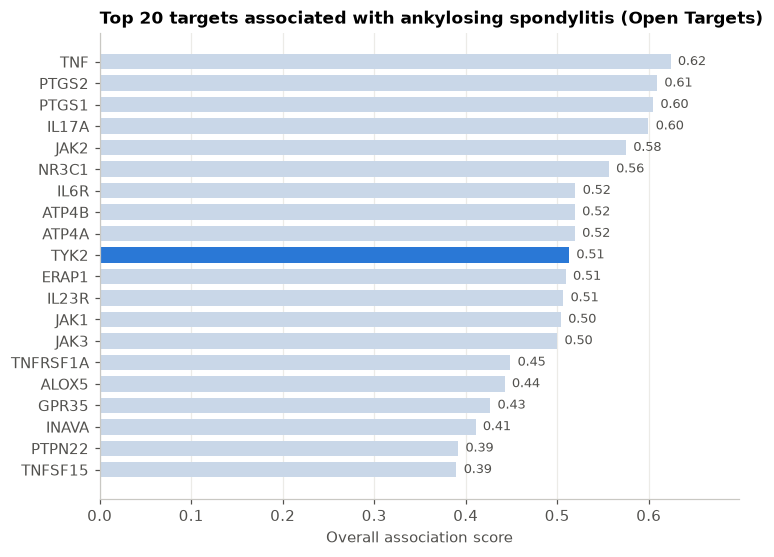

In [3]:
top = assoc.head(20).iloc[::-1]
colors = np.where(top["symbol"] == "TYK2", BLUE, "#c9d7e8")

fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.barh(top["symbol"], top["overall_score"], color=colors, height=0.72)
for y, (s, v) in enumerate(zip(top["symbol"], top["overall_score"])):
    ax.text(v + 0.008, y, f"{v:.2f}", va="center", color=TEXT_2, fontsize=8.5)
ax.set_title("Top 20 targets associated with ankylosing spondylitis (Open Targets)")
ax.set_xlabel("Overall association score")
ax.set_xlim(0, top["overall_score"].max() * 1.12)
ax.grid(axis="y", visible=False)
save(fig, "03_as_target_ranking")
plt.show()

### Where the TYK2 evidence comes from

An overall score hides its composition. A target can rank highly because drugs of its class are
already used in the disease (clinical evidence) rather than because genetics point at it.

In [4]:
evidence = pd.read_csv(OT / "tyk2_as_evidence.csv")
print(evidence.groupby("datatype")["score"].agg(["size", "max"]).round(2))
print("\nClinical evidence is drug-class based:")
print(evidence[evidence["datatype"] == "clinical"]
      .groupby(["drug", "clinical_stage"]).size().to_string())

loci = pd.read_csv(OT / "tyk2_as_gwas_loci.csv")
print(f"\nGWAS credible sets implicating TYK2: {loci['study_locus_id'].nunique()}")
print(loci.groupby("study_locus_id")
      .agg(variants=("rsid", "size"), l2g_tyk2=("l2g_tyk2", "first"),
           best_gene=("l2g_top_gene", "first"), best_score=("l2g_top_score", "first"))
      .round(3).to_string())

                     size   max
datatype                       
clinical               11  1.00
genetic_association     2  0.12
literature              4  0.10

Clinical evidence is drug-class based:
drug          clinical_stage
FILGOTINIB    PHASE_2           2
              PHASE_3           2
TOFACITINIB   PHASE_2           1
              PHASE_2_3         1
              PHASE_3           1
              UNKNOWN           1
UPADACITINIB  APPROVAL          1
              PHASE_2           1
              PHASE_3           1

GWAS credible sets implicating TYK2: 2
                                  variants  l2g_tyk2 best_gene  best_score
study_locus_id                                                            
881e1850d046eee6bb41c323f64b9e7d         1     0.085    RAVER1       0.320
93b9a3f6e17dcd0234dac50f1117d456        25     0.119     PDE4A       0.149


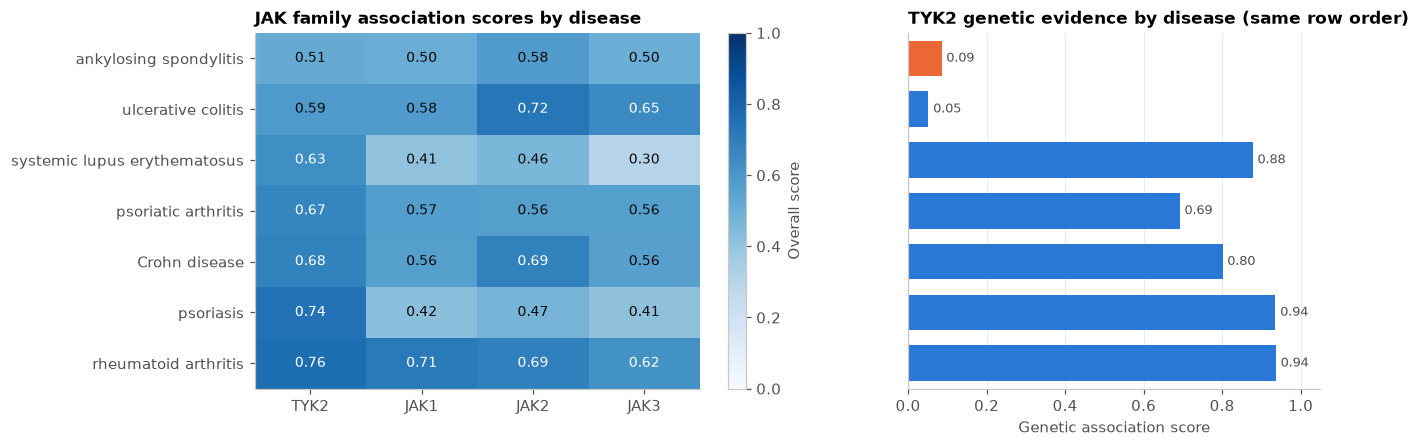

In [5]:
jak = pd.read_csv(OT / "jak_disease_scores.csv")
pivot = jak.pivot(index="disease", columns="target", values="overall_score")
pivot = pivot[["TYK2", "JAK1", "JAK2", "JAK3"]].sort_values("TYK2")
genetic = jak[jak["target"] == "TYK2"].set_index("disease")["genetic_association"]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2), width_ratios=[1.35, 1])

ax = axes[0]
im = ax.imshow(pivot.values, cmap="Blues", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(pivot.columns)), pivot.columns)
ax.set_yticks(range(len(pivot.index)), pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=9,
                color="white" if v > 0.6 else "#0b0b0b")
ax.set_title("JAK family association scores by disease")
ax.grid(visible=False)
fig.colorbar(im, ax=ax, label="Overall score")

ax = axes[1]
# imshow puts row 0 at the top, so invert the bar axis to keep the rows aligned
g = genetic.reindex(pivot.index)
colors = np.where(g.index == "ankylosing spondylitis", ORANGE, BLUE)
ax.barh(range(len(g)), g.values, color=colors, height=0.7)
ax.set_ylim(len(g) - 0.5, -0.5)
ax.set_title("TYK2 genetic evidence by disease (same row order)")
ax.set_xlabel("Genetic association score")
ax.set_yticks([])
ax.set_xlim(0, 1.05)
ax.grid(axis="y", visible=False)
for y, v in enumerate(g.values):
    ax.text(v + 0.012, y, f"{v:.2f}", va="center", color=TEXT_2, fontsize=8.5)
save(fig, "03_jak_disease_evidence")
plt.show()

**Read this carefully.** TYK2's AS association is driven almost entirely by *clinical* evidence,
which here means JAK inhibitors (upadacitinib, tofacitinib, filgotinib) that hit TYK2 among other kinases
and are used in AS. The genetic association for TYK2 in AS is weak (0.09), and the two GWAS credible sets
that touch TYK2 assign the signal to neighbouring genes at least as strongly.

Contrast that with psoriasis (genetic 0.94), psoriatic arthritis (0.69) and Crohn disease (0.80), where TYK2
genetics are strong and where deucravacitinib is approved or in late-stage trials. **TYK2 is a
well-validated target in psoriatic disease; in AS specifically the human genetic case is weak, and the
rationale is mechanistic — the IL-23/IL-17 axis that drives AS signals through TYK2.**

## 3. Selectivity over JAK1/2/3

This is the crux of the target. Pan-JAK inhibition carries class warnings (thrombosis, infection,
malignancy) largely attributed to JAK1/JAK2. A TYK2-selective compound should keep IL-23/IL-12 blockade
without that liability.

Selectivity = pChEMBL(TYK2) − pChEMBL(JAKx), computed from measured (non-binned) values only.

In [6]:
sel = pd.read_csv(PROC / "tyk2_selectivity.csv")
tested = sel[sel["n_jak_tested"] > 0]
print(f"{len(tested)} compounds with measured TYK2 + >=1 JAK value; "
      f"{(sel['n_jak_tested'] == 3).sum()} with the full panel")
print("\nMedian selectivity (log units):")
print(tested.groupby("domain")[["sel_jak1", "sel_jak2", "sel_jak3"]].median().round(2).to_string())

3096 compounds with measured TYK2 + >=1 JAK value; 2061 with the full panel

Median selectivity (log units):
        sel_jak1  sel_jak2  sel_jak3
domain                              
JH1        -0.32      0.00      0.38
JH2        -1.33      0.00      1.20
Other      -0.65     -0.21      0.09


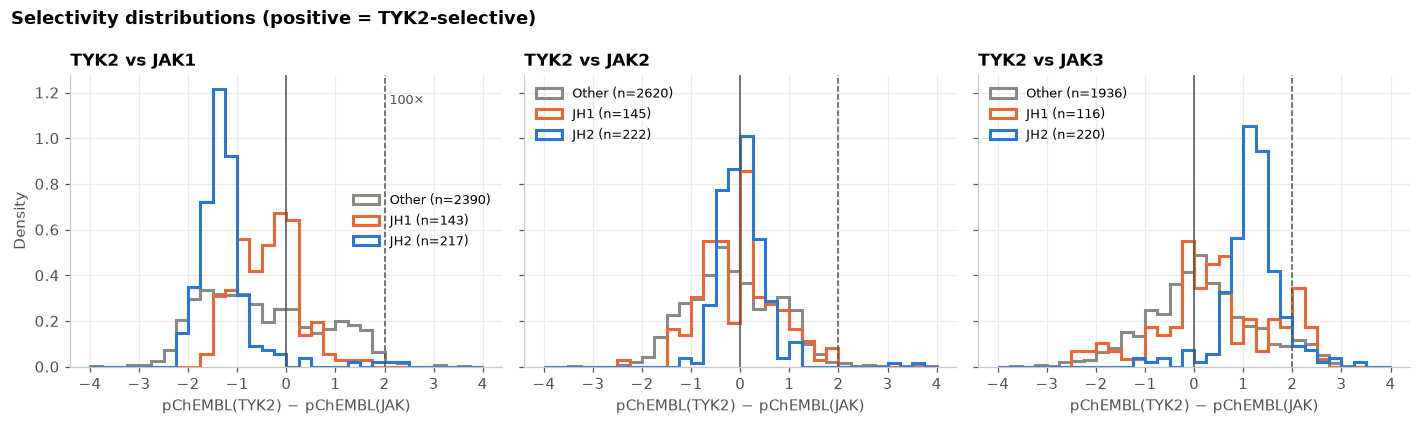

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.9), sharey=True)
for ax, jak in zip(axes, ["jak1", "jak2", "jak3"]):
    for dom in ["Other", "JH1", "JH2"]:
        v = tested.loc[tested["domain"] == dom, f"sel_{jak}"].dropna()
        if len(v) > 20:
            ax.hist(v, bins=np.arange(-4, 4.25, 0.25), histtype="step", linewidth=2,
                    color=DOMAIN_COLORS[dom], label=f"{dom} (n={len(v)})", density=True)
    ax.axvline(0, color=TEXT_2, linewidth=1)
    ax.axvline(2, color=TEXT_2, linestyle="--", linewidth=1)
    ax.set_title(f"TYK2 vs {jak.upper()}")
    ax.set_xlabel("pChEMBL(TYK2) − pChEMBL(JAK)")
    ax.legend(fontsize=8.5)
axes[0].set_ylabel("Density")
axes[0].text(2.1, axes[0].get_ylim()[1] * 0.9, "100×", color=TEXT_2, fontsize=8.5)
fig.suptitle("Selectivity distributions (positive = TYK2-selective)", x=0.01, ha="left",
             fontweight="bold")
fig.tight_layout()
save(fig, "03_selectivity_distributions")
plt.show()

**Most TYK2 chemistry is not TYK2-selective.** Every distribution centres at or below zero: the typical
compound in ChEMBL that hits TYK2 hits JAK1 and JAK2 as hard or harder. The JH2 curve sits *left* of zero
against JAK1, but that comparison is the least trustworthy one — JH2 binding constants versus JAK1
catalytic IC50 measure different sites by different methods, and pan-JAK ATP-site inhibitors profiled
in a JH2 binding assay will look weak on TYK2 by construction.

The signal that matters is the tail on the right, not the centre.

Compounds >=100-fold selective over every JAK tested: 24
  like-for-like (excluding cross-assay JH2): 21
  profiled against all three JAKs: 4


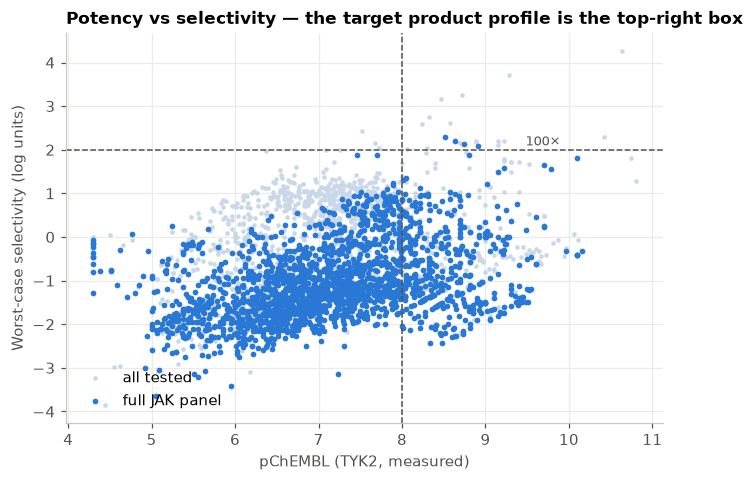

In [8]:
strict = tested[tested["min_selectivity"] >= 2]
same_assay = strict[~strict["cross_assay"]]
print(f"Compounds >=100-fold selective over every JAK tested: {len(strict)}")
print(f"  like-for-like (excluding cross-assay JH2): {len(same_assay)}")
print(f"  profiled against all three JAKs: {(strict['n_jak_tested'] == 3).sum()}")

fig, ax = plt.subplots(figsize=(7, 4.6))
ax.scatter(tested["p_tyk2"], tested["min_selectivity"], s=9, linewidths=0,
           color="#c9d7e8", label="all tested")
full = tested[tested["n_jak_tested"] == 3]
ax.scatter(full["p_tyk2"], full["min_selectivity"], s=14, linewidths=0,
           color=BLUE, label="full JAK panel")
ax.axhline(2, color=TEXT_2, linestyle="--", linewidth=1)
ax.axvline(8, color=TEXT_2, linestyle="--", linewidth=1)
ax.set_xlabel("pChEMBL (TYK2, measured)")
ax.set_ylabel("Worst-case selectivity (log units)")
ax.set_title("Potency vs selectivity — the target product profile is the top-right box")
ax.legend(loc="lower left")
ax.text(9.9, 2.1, "100×", color=TEXT_2, fontsize=8.5, ha="right")
save(fig, "03_potency_vs_selectivity")
plt.show()

## 4. QSAR models

Two models, each cross-validated under a random split and a scaffold-grouped split.
The scaffold split is the honest one: notebook 02 showed 91% of compounds have a near-duplicate
neighbour, so a random split leaks close analogues between train and test.

In [9]:
metrics = pd.read_csv(RES / "model_metrics.csv")
reg = metrics[metrics["task"] == "regression"]
clf = metrics[metrics["task"] == "classification"]
print("Regression (pChEMBL, measured values only):")
print(reg[["split", "model", "rmse_mean", "rmse_std", "mae_mean", "r2_mean", "spearman_mean"]]
      .to_string(index=False))
print("\nClassification (active = pChEMBL >= 7):")
print(clf[["split", "model", "roc_auc_mean", "pr_auc_mean", "balanced_accuracy_mean", "mcc_mean"]]
      .to_string(index=False))

Regression (pChEMBL, measured values only):
   split         model  rmse_mean  rmse_std  mae_mean  r2_mean  spearman_mean
  random mean_baseline      1.086     0.025     0.875   -0.001          0.000
  random random_forest      0.648     0.037     0.463    0.644          0.800
scaffold mean_baseline      1.087     0.051     0.876   -0.004          0.000
scaffold random_forest      0.734     0.038     0.533    0.539          0.729

Classification (active = pChEMBL >= 7):
   split          model  roc_auc_mean  pr_auc_mean  balanced_accuracy_mean  mcc_mean
  random prior_baseline         0.500        0.710                   0.500     0.000
  random  random_forest         0.944        0.978                   0.871     0.717
scaffold prior_baseline         0.500        0.711                   0.500     0.000
scaffold  random_forest         0.925        0.971                   0.844     0.657


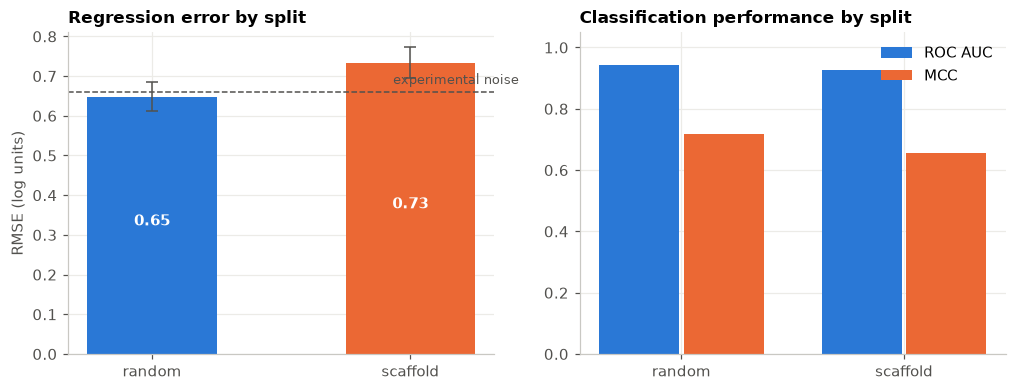

In [10]:
rf = metrics[metrics["model"] == "random_forest"]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

ax = axes[0]
r = rf[rf["task"] == "regression"].set_index("split").loc[["random", "scaffold"]]
ax.bar(r.index, r["rmse_mean"], yerr=r["rmse_std"], width=0.5, color=[BLUE, ORANGE],
       capsize=4, error_kw={"ecolor": TEXT_2, "lw": 1})
ax.axhline(0.66, color=TEXT_2, linestyle="--", linewidth=1)
ax.text(1.42, 0.68, "experimental noise", color=TEXT_2, fontsize=8.5, ha="right")
for x, v in enumerate(r["rmse_mean"]):
    ax.text(x, v / 2, f"{v:.2f}", ha="center", color="white", fontweight="bold")
ax.set_title("Regression error by split")
ax.set_ylabel("RMSE (log units)")

ax = axes[1]
c = rf[rf["task"] == "classification"].set_index("split").loc[["random", "scaffold"]]
x = np.arange(2)
ax.bar(x - 0.19, c["roc_auc_mean"], 0.36, color=BLUE, label="ROC AUC")
ax.bar(x + 0.19, c["mcc_mean"], 0.36, color=ORANGE, label="MCC")
ax.set_xticks(x, c.index)
ax.set_ylim(0, 1.05)
ax.set_title("Classification performance by split")
ax.legend()
save(fig, "03_model_performance")
plt.show()

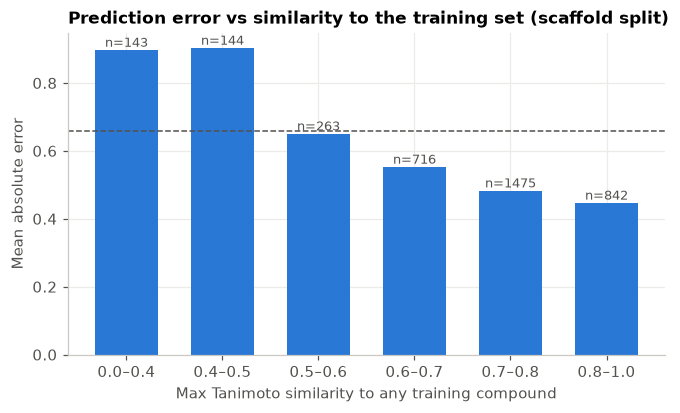

                n    mae
sim_bin                 
[0.0, 0.4)    143  0.897
[0.4, 0.5)    144  0.903
[0.5, 0.6)    263  0.650
[0.6, 0.7)    716  0.552
[0.7, 0.8)   1475  0.482
[0.8, 1.01)   842  0.446


In [11]:
# Does accuracy decay with distance from the training set?
oof = pd.read_csv(RES / "cv_predictions.csv")
r = oof[(oof["task"] == "regression") & (oof["split"] == "scaffold")].copy()
r["error"] = (r["y_pred"] - r["y_true"]).abs()
bins = [0, 0.4, 0.5, 0.6, 0.7, 0.8, 1.01]
r["sim_bin"] = pd.cut(r["max_train_sim"], bins, right=False)
grp = r.groupby("sim_bin", observed=True).agg(n=("error", "size"), mae=("error", "mean"))

fig, ax = plt.subplots(figsize=(7, 3.8))
labels = [f"{i.left:.1f}–{i.right:.1f}" for i in grp.index]
ax.bar(labels, grp["mae"], color=BLUE, width=0.65)
for x, (v, n) in enumerate(zip(grp["mae"], grp["n"])):
    ax.text(x, v + 0.01, f"n={n}", ha="center", color=TEXT_2, fontsize=8.5)
ax.axhline(0.66, color=TEXT_2, linestyle="--", linewidth=1)
ax.set_title("Prediction error vs similarity to the training set (scaffold split)")
ax.set_xlabel("Max Tanimoto similarity to any training compound")
ax.set_ylabel("Mean absolute error")
save(fig, "03_applicability_domain")
plt.show()
print(grp.round(3).to_string())

The model is only trustworthy close to what it has already seen. Beyond Tanimoto ≈ 0.5 from the training
set, error approaches the spread of the data itself — so this model ranks analogues within known series,
it does not discover new chemotypes.

## 5. Candidate prioritisation

Hard filters: potency ≤ 10 nM, ≥ 100-fold selectivity over every JAK tested, ≤ 1 Lipinski violation,
TPSA ≤ 140, no PAINS alerts. Survivors are scored on potency, selectivity, how complete the off-target
profile is, ligand efficiency and QED, then capped at two per scaffold.

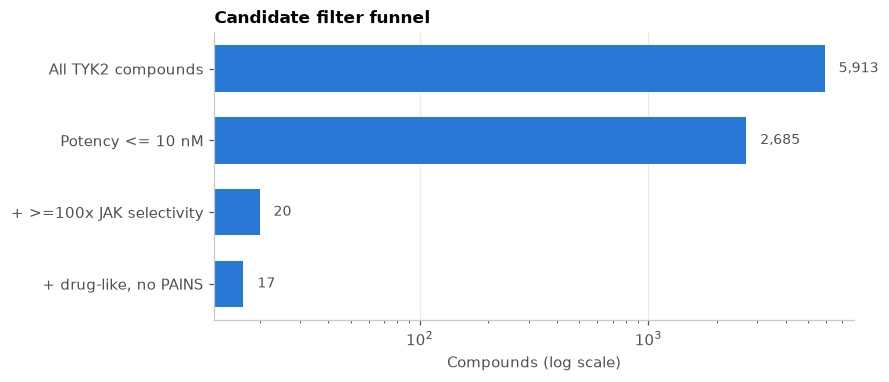

In [12]:
ranked = pd.read_csv(RES / "candidate_ranking.csv")
top = pd.read_csv(RES / "top_candidates.csv")
compounds = pd.read_csv(PROC / "tyk2_compounds.csv")

sel_all = pd.read_csv(PROC / "tyk2_selectivity.csv")
potent = compounds[compounds["pchembl_median"] >= 8]
potent_sel = potent.merge(sel_all[["smiles_std", "min_selectivity", "n_jak_tested"]], on="smiles_std")
funnel = {
    "All TYK2 compounds": len(compounds),
    "Potency <= 10 nM": len(potent),
    "+ >=100x JAK selectivity": int(((potent_sel["n_jak_tested"] > 0)
                                     & (potent_sel["min_selectivity"] >= 2)).sum()),
    "+ drug-like, no PAINS": len(ranked),
}
fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.barh(list(funnel)[::-1], list(funnel.values())[::-1], color=BLUE, height=0.65)
ax.set_xscale("log")
for y, v in enumerate(list(funnel.values())[::-1]):
    ax.text(v * 1.15, y, f"{v:,}", va="center", color=TEXT_2, fontsize=9)
ax.set_title("Candidate filter funnel")
ax.set_xlabel("Compounds (log scale)")
ax.grid(axis="y", visible=False)
save(fig, "03_candidate_funnel")
plt.show()

In [13]:
cols = ["molecule_chembl_id", "reference_drug", "score", "pchembl_median", "domain",
        "min_selectivity", "n_jak_tested", "ligand_efficiency", "qed", "mw"]
top[cols].round(2)

,molecule_chembl_id,reference_drug,score,pchembl_median,domain,min_selectivity,n_jak_tested,ligand_efficiency,qed,mw
0,CHEMBL4440718,NaN,0.68,9.28,JH2,3.71,1,0.45,0.57,401.47
1,CHEMBL5417355,NaN,0.62,10.42,JH2,2.29,1,0.53,0.70,382.45
2,CHEMBL5422616,NaN,0.51,8.77,Other,3.17,2,0.35,0.38,460.50
3,CHEMBL5419627,NaN,0.50,8.91,JH2,2.08,3,0.38,0.53,437.46
4,CHEMBL4074130,NaN,0.48,9.22,Other,2.20,1,0.53,0.57,357.20
5,CHEMBL4099854,NaN,0.47,9.15,Other,2.19,1,0.48,0.54,387.23
6,CHEMBL4435170,deucravacitinib,0.46,8.52,Other,2.29,3,0.38,0.52,425.47
7,CHEMBL4092191,NaN,0.46,9.15,Other,2.12,1,0.48,0.52,381.23
8,CHEMBL5561392,NaN,0.46,8.89,Other,2.20,2,0.41,0.47,397.49
9,CHEMBL5558196,NaN,0.45,8.64,Other,2.21,3,0.36,0.49,443.47


### Does the method recover the drug that already works?

Deucravacitinib is the only approved TYK2-selective inhibitor. It was **not** given any special
treatment — it is simply a compound in ChEMBL. If the filters are sensible, it should survive them.

In [14]:
refs = ranked[ranked["reference_drug"].notna()]
print("Clinical TYK2-directed drugs that pass every filter:")
print(refs[["reference_drug", "score", "pchembl_median", "min_selectivity", "n_jak_tested"]]
      .round(2).to_string(index=False))

deu_rank = ranked.reset_index(drop=True).query("reference_drug == 'deucravacitinib'").index
print(f"\nDeucravacitinib rank: {int(deu_rank[0]) + 1} of {len(ranked)} passing compounds")

Clinical TYK2-directed drugs that pass every filter:
 reference_drug  score  pchembl_median  min_selectivity  n_jak_tested
deucravacitinib   0.46            8.52             2.29             3

Deucravacitinib rank: 7 of 17 passing compounds


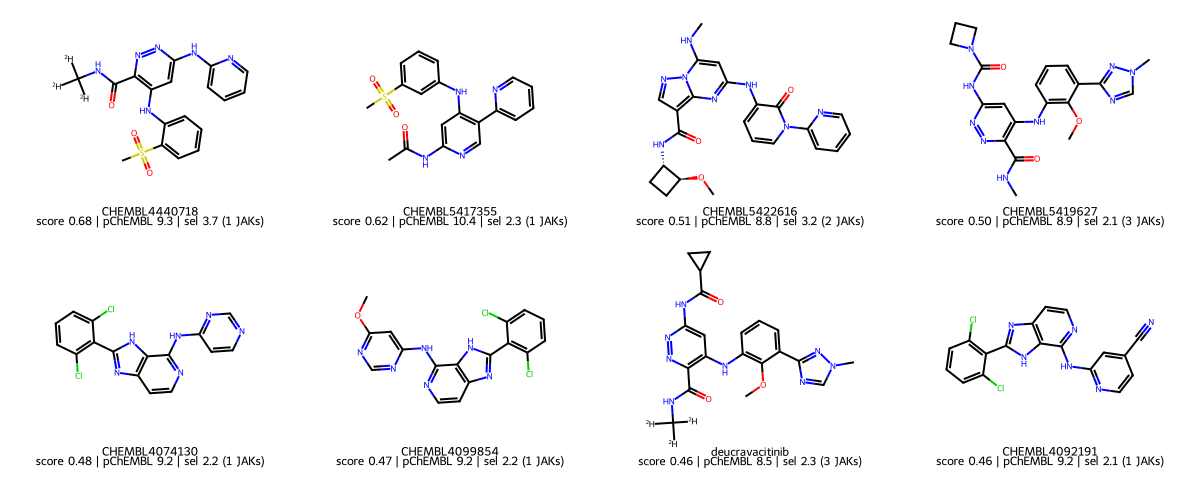

In [15]:
mols, legends = [], []
for r in top.head(8).itertuples():
    mols.append(Chem.MolFromSmiles(r.smiles_std))
    name = r.reference_drug if isinstance(r.reference_drug, str) else r.molecule_chembl_id
    legends.append(f"{name}\nscore {r.score:.2f} | pChEMBL {r.pchembl_median:.1f} | "
                   f"sel {r.min_selectivity:.1f} ({r.n_jak_tested} JAKs)")
img = Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(300, 240), legends=legends,
                           returnPNG=False)
img.save(FIG_DIR / "03_top_candidates.png")
img

## 6. Conclusions

**Target.** TYK2 ranks 10th of 1,743 targets associated with ankylosing spondylitis in Open Targets, but
that position is built on clinical precedent for pan-JAK drugs, not on AS genetics (genetic score 0.09,
and the GWAS credible sets nearby assign their signal to other genes at least as strongly). The strong
human genetic validation of TYK2 sits in psoriasis (0.94), rheumatoid arthritis (0.94), SLE (0.88) and
Crohn disease (0.80). For AS the honest statement is: **mechanistically well-motivated through the
IL-23/IL-17 axis and supported by clinical precedent in related spondyloarthropathies, but not yet
genetically validated in AS itself.**

**Selectivity is the whole ballgame, and it is rare.** Of 5,913 TYK2 compounds, only 3,096 have measured
values against any other JAK, and just 21 clear 100-fold selectivity over every JAK they were tested
against on a like-for-like basis. The median compound is *not* TYK2-selective. This is consistent with
why deucravacitinib (a JH2 allosteric binder) was a genuine breakthrough rather than an incremental one:
the ATP site is too conserved across the family.

**Models.** A Morgan-fingerprint random forest predicts pChEMBL with RMSE 0.73 under a scaffold split
(0.65 random) against experimental noise of about 0.66, and classifies actives at ROC AUC 0.93 (0.94
random). The gap between splits is the honest measure of novelty penalty, and error rises sharply beyond
Tanimoto 0.5 from the training set. Useful for ranking analogues; not for finding new chemotypes.

**Candidates.** 17 compounds pass every filter, spanning 15 scaffolds. Deucravacitinib passes and ranks
7th without any special handling, while all 12 other clinical JAK-family drugs in the dataset fail on
selectivity. That the method recovers the one approved TYK2-selective drug, and rejects the pan-JAK
inhibitors, is the strongest available check that the filters encode the right target product profile.

### Limitations

- **Binned data.** 37% of TYK2 records come from patents reporting ranges. They are excluded from
  regression and from all selectivity maths, but they still shape the classification set.
- **Cross-assay selectivity.** JH2 binding constants versus JAK catalytic IC50s are not like-for-like.
  Flagged in the data, but it limits what can be concluded for the allosteric series.
- **Sparse off-target data.** Most candidates were profiled against only one or two JAKs. Scoring
  penalises this, but it cannot substitute for a full panel.
- **No structural work.** No docking or free-energy calculation was done; selectivity here is empirical.
- **Public data only.** ChEMBL is biased toward published (and patented) chemistry, and the most
  advanced compounds are often the least completely reported.

### If this went further

1. Profile the 17 candidates against the full JAK panel in one consistent assay format.
2. Bring in a JH2 structure (PDB 4WOV and successors) and dock the shortlist to test whether the
   selective compounds share an allosteric binding mode.
3. Add AS-specific pharmacology: IL-23-driven STAT3 phosphorylation in primary human cells.
4. Revisit the genetics as AS GWAS sample sizes grow — the current weak TYK2 signal may be power-limited.